Multi-Task DNN - 3-Class Classification + Regression

Novel contribution: dual-output architecture with 3-class classification
head (peak return magnitude) trained jointly with a regression head.
- Classification: <2% (Class 0), 2-4% (Class 1), ≥4% (Class 2)
- Regression: peak return magnitude
- Flat encoder over all features

**How this notebook is organized:**
0. Setup - mount Drive, imports, device/seed config
1. Data Loading - join tech/fundamentals/sentiment/sector into one table
2. Feature List - flatten everything into a single input vector
3. Fold Construction - quarterly walk-forward train/val/test splits
4. Architecture & Training Function - shared encoder + dual heads
5. Baseline Run - default hyperparameters, no tuning
6. Hyperparameter Search & Final Tuned Model - two-phase Optuna search
7. Visualizations - accuracy over time, confusion matrix, return spread
8. Model Diagnostics - precision/recall, calibration, loss decomposition
9. Save Results - pickle outputs for cross-pipeline comparison


## Setup

Uses the repository's local model-staging parquet files. Set `MODEL_STAGING_DIR` to override automatic local discovery.


In [1]:
from pathlib import Path
import os

def find_model_staging_dir():
    candidates = []
    if os.environ.get('MODEL_STAGING_DIR'):
        candidates.append(Path(os.environ['MODEL_STAGING_DIR']).expanduser())
    cwd = Path.cwd().resolve()
    candidates.extend(parent / 'src/data/model_staging' for parent in [cwd, *cwd.parents])
    for path in candidates:
        if (path / 'tech_modeling_table.parquet').exists():
            return path
    raise FileNotFoundError('Set MODEL_STAGING_DIR to the directory containing tech_modeling_table.parquet')

MODEL_STAGING_DIR = find_model_staging_dir()
print(f'Model staging data: {MODEL_STAGING_DIR}')

Model staging data: /Users/richardpears/github/Post-Earnings-Forecast/src/data/model_staging


### Imports, Device, and Reproducibility

Pulls in Polars (data loading/joins), PyTorch (the multi-task DNN), scikit-learn (imputation, scaling, metrics), and Optuna (hyperparameter search). `set_seed()` is called at the start of every training run so folds are reproducible. Picks GPU if available, otherwise falls back to CPU. The `plt.rcParams` block forces a white background / black text theme so plots render legibly regardless of notebook theme.


In [2]:

import polars as pl
import numpy as np
import os, pickle, re, random, json

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.labelcolor']  = 'black'
plt.rcParams['xtick.color']      = 'black'
plt.rcParams['ytick.color']      = 'black'
plt.rcParams['axes.edgecolor']   = 'black'

Using device: cpu


/Users/richardpears/github/Post-Earnings-Forecast/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

Joins tech indicators + fundamentals + FinBERT transcript sentiment + news sentiment + sector one-hot into a single modeling table, keyed on `(symbol, earnings_date)`. Identical to the TabNet notebook's data loading, so both advanced models are evaluated on the same information.

In [5]:

df_tech = pl.read_parquet(MODEL_STAGING_DIR / "tech_modeling_table.parquet")
print(f"Tech table shape: {df_tech.shape}")

df_fund = pl.read_parquet(MODEL_STAGING_DIR / "modeling_fundamentals.parquet")
df_fund = df_fund.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin",     "gross_margin_qoq",
    "debt_to_equity",   "debt_to_equity_qoq",
    "fcf_margin",       "fcf_margin_qoq",
    "roe",              "roe_qoq",
    "surprisePercentage",
])

# Read FinBERT once, extract both sentiment and sector
df_finbert_raw = pl.read_parquet(MODEL_STAGING_DIR / "finbert_tx_agg_weighted.parquet")

df_finbert = df_finbert_raw.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "pos_prob", "neg_prob",
])

df_nz = pl.read_parquet(MODEL_STAGING_DIR / "nz_sentiment.parquet")
df_nz = df_nz.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre",  "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
])

df_model = df_tech.join(df_fund,     on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_nz,      on=["symbol", "earnings_date"], how="left")

# Sector one-hot (from same FinBERT parquet, no second read)
df_sector = df_finbert_raw.select(["symbol", "sector"]).unique()
df_sector = df_sector.with_columns(pl.col("sector").fill_null("Unknown"))
sectors = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")
df_model = df_model.join(df_sector, on="symbol", how="left")

# Drop CAR columns (not used in this model)
df_model = df_model.drop([
    col for col in df_model.columns if col.startswith("car")
])

print(f"Combined table shape: {df_model.shape}")
print(f"Target class distribution:\n{df_model['target_class'].value_counts().sort('target_class')}")

Tech table shape: (24048, 243)
Combined table shape: (24048, 270)
Target class distribution:
shape: (3, 2)
┌──────────────┬───────┐
│ target_class ┆ count │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 0            ┆ 7955  │
│ 1            ┆ 6428  │
│ 2            ┆ 9665  │
└──────────────┴───────┘


### Sanity Checks

Two checks before moving on: (1) the join sequence didn't duplicate rows - a common failure mode when a joined table has more than one row per key - and (2) a quick per-modality null rate, so a suspiciously high NaN rate (e.g. a broken join key) gets caught here rather than silently degrading the model later.


In [6]:
n_expected = len(df_tech)
n_actual   = len(df_model)
assert n_actual == n_expected, (
    f"Row count changed after joins: {n_expected} → {n_actual}. "
    f"Check for duplicate keys in sector/fundamentals."
)

# NaN rate per joined modality - anything above ~15% is worth investigating
for modality, cols in [
    ("fundamentals", ["eps_growth_qoq", "surprisePercentage"]),
    ("finbert",      ["pos_prob", "neg_prob"]),
    ("nz_sentiment", ["overall_sentiment_score_pre"]),
    ("sector",       [c for c in df_model.columns if c.startswith("sector_")]),
]:
    check_col = cols[0]
    nan_rate = df_model[check_col].is_null().mean()
    print(f"  {modality:15s} NaN rate: {nan_rate:.1%}")

  fundamentals    NaN rate: 2.0%
  finbert         NaN rate: 0.0%
  nz_sentiment    NaN rate: 0.0%
  sector          NaN rate: 0.0%


## 2. Feature List (Flat, Single Encoder)

All 257 features are concatenated into one flat vector - no per-modality encoders. The tech/VIX sequence columns are kept grouped and ordered by timestep purely so a future sequence-pooling ablation could slice them out without rebuilding folds; the model itself treats the whole vector as flat input regardless of this ordering.

In [7]:

exc = [
 'target_return_close_t10',
 'target_class_close_t10',
 'target_return_avg_high',
 'target_class_avg_high',
 'car_3day',
 'car_t2_t10',
 'max_high',
 'min_high',
 'max_day',
 'min_day']
EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_class", "max_high", "min_high", "max_day", "min_day", "year", "quarter",
] + exc
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]

TECH_BASES = [
    "rsi", "macd", "macd_hist", "roc",
    "ema50_pct", "ema200_pct", "ema50_200_pct", "adx",
    "atr", "bb_width", "bb_pct_b", "sigma",
    "obv_zscore", "vwap_pct",
    "open_pct", "high_pct", "low_pct", "volume_rel",
]
VIX_BASES = ["vix_close"]
SEQ_BASES = TECH_BASES + VIX_BASES  # 19 indicators × 12 timesteps

def group_sequence_columns(all_cols, bases):
    groups = {}
    remaining = list(all_cols)
    for base in sorted(bases, key=len, reverse=True):
        matched = [c for c in remaining if c == base or c.startswith(base + "_")]
        def step_key(col, base=base):
            m = re.search(r"(-?\d+)", col[len(base):])
            return int(m.group(1)) if m else 0
        groups[base] = sorted(matched, key=step_key)
        remaining = [c for c in remaining if c not in matched]
    return {base: groups[base] for base in bases}

seq_groups = group_sequence_columns(feature_cols, SEQ_BASES)
timestep_counts = {len(c) for c in seq_groups.values()}
assert len(timestep_counts) == 1, f"Inconsistent timestep counts: {timestep_counts}"
n_timesteps = timestep_counts.pop()
seq_cols_ordered = [c for base in SEQ_BASES for c in seq_groups[base]]

other_cols = [c for c in feature_cols if c not in seq_cols_ordered]

flat_feature_cols = seq_cols_ordered + other_cols

assert len(flat_feature_cols) == len(feature_cols), (
    f"Feature count mismatch: flat={len(flat_feature_cols)}, original={len(feature_cols)}"
)
print(f"Sequence block: {len(seq_cols_ordered)} cols ({len(SEQ_BASES)} indicators × {n_timesteps} steps)")
print(f"Other (fundamentals/sentiment/sector): {len(other_cols)} cols")
print(f"Total flat features: {len(flat_feature_cols)}")

Sequence block: 228 cols (19 indicators × 12 steps)
Other (fundamentals/sentiment/sector): 29 cols
Total flat features: 257


## 3. Fold Construction - Quarterly Expanding Window

Builds walk-forward folds so the model is never evaluated on data it could have seen during training. For each fold:
- **Train** = everything before the validation quarter
- **Val** = the single quarter immediately before the test quarter (used only for early stopping)
- **Test** = the held-out quarter

The window expands forward through time - fold *N+1*'s training set is a superset of fold *N*'s. Imputation and scaling (`prep_block`) are fit on the training split only and applied unchanged to val/test, so no information about the future leaks into preprocessing.


In [8]:

def prep_block(train_df, val_df, test_df, cols):
    """Fit imputer + scaler on train ONLY. Val and test are transform-only."""
    Xtr = train_df.select(cols).to_numpy()
    Xva = val_df.select(cols).to_numpy()
    Xte = test_df.select(cols).to_numpy()

    Xtr = np.where(np.isinf(Xtr), np.nan, Xtr)
    Xva = np.where(np.isinf(Xva), np.nan, Xva)
    Xte = np.where(np.isinf(Xte), np.nan, Xte)

    imputer = SimpleImputer(strategy="median").fit(Xtr)
    Xtr = imputer.transform(Xtr)
    Xva = imputer.transform(Xva)
    Xte = imputer.transform(Xte)

    scaler = StandardScaler().fit(Xtr)
    return scaler.transform(Xtr), scaler.transform(Xva), scaler.transform(Xte)


INITIAL_TRAIN_YEARS = 7

df_model = df_model.with_columns([
    pl.col("earnings_date").dt.year().alias("year"),
    pl.col("earnings_date").dt.quarter().alias("quarter"),
])

df_model = df_model.filter(pl.col("year") <= 2025)

min_date = df_model["earnings_date"].min()
max_date = df_model["earnings_date"].max()
print(f"Dataset spans: {min_date} to {max_date}")
print(f"Total rows: {len(df_model)}\n")

unique_quarters = df_model.select(["year", "quarter"]).unique().sort(["year", "quarter"])
quarters_list = unique_quarters.to_dicts()

print("=" * 100)
print("EXPANDING WINDOW FOLD CONSTRUCTION (val = quarter before test)")
print("=" * 100)

earliest_year = quarters_list[0]["year"]
initial_train_end_year = earliest_year + INITIAL_TRAIN_YEARS - 1  # 2019
first_test_idx = next(i for i, q in enumerate(quarters_list) if q["year"] > initial_train_end_year)

print(f"Initial training period: {earliest_year}–{initial_train_end_year}")
print(f"Testing begins at: {quarters_list[first_test_idx]}")
print("=" * 100 + "\n")

folds_data = []
fold_num = 1

for test_quarter_idx in range(first_test_idx, len(quarters_list)):
    test_q = quarters_list[test_quarter_idx]
    val_q  = quarters_list[test_quarter_idx - 1]
    test_label = f"{test_q['year']}_Q{test_q['quarter']}"

    test_data = df_model.filter(
        (pl.col("year") == test_q["year"]) & (pl.col("quarter") == test_q["quarter"])
    )

    val_data = df_model.filter(
        (pl.col("year") == val_q["year"]) & (pl.col("quarter") == val_q["quarter"])
    )

    train_data = df_model.filter(
        (pl.col("year") < val_q["year"]) |
        ((pl.col("year") == val_q["year"]) & (pl.col("quarter") < val_q["quarter"]))
    )

    if len(train_data) == 0 or len(val_data) == 0 or len(test_data) == 0:
        continue

    X_tr, X_va, X_te = prep_block(train_data, val_data, test_data, flat_feature_cols)

    folds_data.append({
        "fold_num":     fold_num,
        "test_quarter": test_label,
        "X_train":      X_tr,
        "X_val":        X_va,
        "X_test":       X_te,
        "y_train_cls":  train_data["target_class"].to_numpy(),
        "y_val_cls":    val_data["target_class"].to_numpy(),
        "y_test_cls":   test_data["target_class"].to_numpy(),
        "y_train_ret":  train_data["target_return"].to_numpy(),
        "y_val_ret":    val_data["target_return"].to_numpy(),
        "y_test_ret":   test_data["target_return"].to_numpy(),
    })

    print(f"Fold {fold_num:2d} [{test_label}]:  "
          f"train={X_tr.shape[0]:6,}  "
          f"val={X_va.shape[0]:4,} ({val_q['year']}_Q{val_q['quarter']})  "
          f"test={X_te.shape[0]:4,}")

    fold_num += 1

n_features = len(flat_feature_cols)
print("=" * 100)
print(f"Total folds: {len(folds_data)}")
print(f"n_features: {n_features}")
print("=" * 100)

Dataset spans: 2014-01-07 to 2025-12-19
Total rows: 23106

EXPANDING WINDOW FOLD CONSTRUCTION (val = quarter before test)
Initial training period: 2014–2020
Testing begins at: {'year': 2021, 'quarter': 1}

Fold  1 [2021_Q1]:  train=12,683  val= 486 (2020_Q4)  test= 492
Fold  2 [2021_Q2]:  train=13,169  val= 492 (2021_Q1)  test= 493
Fold  3 [2021_Q3]:  train=13,661  val= 493 (2021_Q2)  test= 493
Fold  4 [2021_Q4]:  train=14,154  val= 493 (2021_Q3)  test= 492
Fold  5 [2022_Q1]:  train=14,647  val= 492 (2021_Q4)  test= 494
Fold  6 [2022_Q2]:  train=15,139  val= 494 (2022_Q1)  test= 495
Fold  7 [2022_Q3]:  train=15,633  val= 495 (2022_Q2)  test= 493
Fold  8 [2022_Q4]:  train=16,128  val= 493 (2022_Q3)  test= 493
Fold  9 [2023_Q1]:  train=16,621  val= 493 (2022_Q4)  test= 492
Fold 10 [2023_Q2]:  train=17,114  val= 492 (2023_Q1)  test= 498
Fold 11 [2023_Q3]:  train=17,606  val= 498 (2023_Q2)  test= 496
Fold 12 [2023_Q4]:  train=18,104  val= 496 (2023_Q3)  test= 498
Fold 13 [2024_Q1]:  train=

## 4. Multi-Task DNN - Architecture & Training Function

**Shared encoder:** [256, 128, 64] with BatchNorm + ReLU + Dropout(0.3) at each layer.
- **Classification head:** Linear(64→32) → ReLU → Linear(32→3)
- **Regression head:** Linear(64→32) → ReLU → Linear(32→1)

**Joint loss:** alpha × CrossEntropy + (1-alpha) × MSE.
Regression target is z-scored using training-set statistics only, unscaled at prediction.
Fixed epochs, no early stopping, no validation (professor's requirement).
Regularization: dropout + weight_decay + BatchNorm + fixed epoch count.

In [9]:
"""## 4. Multi-Task DNN - Architecture & Training Function

Shared encoder: [256, 128, 64] with BatchNorm + ReLU + Dropout.
- Classification head: Linear(64→32) → ReLU → Linear(32→3)
- Regression head: Linear(64→32) → ReLU → Linear(32→1)

Joint loss: alpha × CrossEntropy + (1-alpha) × MSE.
Regression target z-scored using training-set statistics only.
Early stopping on validation quarter (quarter before test),
with a minimum epoch floor to prevent premature stopping.
Regularization: dropout + weight_decay + BatchNorm + cosine LR schedule.
"""

def build_dnn(n_features, hidden=(256, 128, 64), head_hidden=32, n_classes=3, dropout=0.3):
    layers = []
    in_dim = n_features
    for h in hidden:
        layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    encoder = nn.Sequential(*layers)
    clf_head = nn.Sequential(nn.Linear(in_dim, head_hidden), nn.ReLU(), nn.Linear(head_hidden, n_classes))
    reg_head = nn.Sequential(nn.Linear(in_dim, head_hidden), nn.ReLU(), nn.Linear(head_hidden, 1))
    return nn.ModuleDict({"encoder": encoder, "clf_head": clf_head, "reg_head": reg_head})


def dnn_forward(modules, x):
    h = modules["encoder"](x)
    return modules["clf_head"](h), modules["reg_head"](h).squeeze(-1)


def train_dnn(f, n_features, hidden=(256, 128, 64), head_hidden=32, dropout=0.3,
              alpha=0.5, max_epochs=50, patience=15, min_epochs=15,
              batch_size=512, lr=1e-3, weight_decay=1e-4,
              seed=42, use_class_weights=True):
    """Train with early stopping on validation quarter.
    Model trains for at least min_epochs before early stopping can fire.
    Restores best weights when validation loss stops improving.
    """
    set_seed(seed)
    modules = build_dnn(n_features, hidden=hidden, head_hidden=head_hidden, dropout=dropout).to(device)

    y_mean, y_std = f["y_train_ret"].mean(), f["y_train_ret"].std()

    Xtr     = torch.FloatTensor(f["X_train"]).to(device)
    ytr_cls = torch.LongTensor(f["y_train_cls"]).to(device)
    ytr_ret = torch.FloatTensor((f["y_train_ret"] - y_mean) / y_std).to(device)

    Xva     = torch.FloatTensor(f["X_val"]).to(device)
    yva_cls = torch.LongTensor(f["y_val_cls"]).to(device)
    yva_ret = torch.FloatTensor((f["y_val_ret"] - y_mean) / y_std).to(device)

    Xte     = torch.FloatTensor(f["X_test"]).to(device)

    train_ds     = TensorDataset(Xtr, ytr_cls, ytr_ret)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)

    # Class weights: inverse-frequency
    if use_class_weights:
        classes, counts = np.unique(f["y_train_cls"], return_counts=True)
        assert len(classes) == 3, f"Training set missing a class - found {classes}"
        weights = 1.0 / counts
        weights = weights / weights.sum() * len(classes)
        class_weights = torch.FloatTensor(weights).to(device)
    else:
        class_weights = None

    clf_loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    reg_loss_fn = nn.MSELoss()
    optimizer   = torch.optim.Adam(modules.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    # Training loop with early stopping
    history = {"total": [], "clf": [], "reg": [], "train_acc": [], "val_loss": []}
    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # ── Train ───────────────────────────────────────────────────
        modules.train()
        epoch_loss, epoch_clf, epoch_reg = 0.0, 0.0, 0.0
        correct, total = 0, 0

        for xb, yb_cls, yb_ret in train_loader:
            optimizer.zero_grad()
            clf_logits, reg_out = dnn_forward(modules, xb)
            l_clf = clf_loss_fn(clf_logits, yb_cls)
            l_reg = reg_loss_fn(reg_out, yb_ret)
            loss  = alpha * l_clf + (1 - alpha) * l_reg
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modules.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)
            epoch_clf  += l_clf.item() * xb.size(0)
            epoch_reg  += l_reg.item() * xb.size(0)
            correct    += (clf_logits.argmax(1) == yb_cls).sum().item()
            total      += xb.size(0)

        history["total"].append(epoch_loss / total)
        history["clf"].append(epoch_clf / total)
        history["reg"].append(epoch_reg / total)
        history["train_acc"].append(correct / total)
        scheduler.step()

        # ── Validate ────────────────────────────────────────────────
        modules.eval()
        with torch.no_grad():
            val_clf_logits, val_reg_out = dnn_forward(modules, Xva)
            val_l_clf = clf_loss_fn(val_clf_logits, yva_cls)
            val_l_reg = reg_loss_fn(val_reg_out, yva_ret)
            val_loss  = alpha * val_l_clf + (1 - alpha) * val_l_reg
            val_loss  = val_loss.item()

        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in modules.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # Early stopping only after min_epochs
        if epochs_no_improve >= patience and epoch >= min_epochs:
            break

    # Restore best weights
    modules.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    # ── Inference ───────────────────────────────────────────────────
    modules.eval()
    with torch.no_grad():
        test_clf_logits, test_reg_out = dnn_forward(modules, Xte)
        test_clf_probs = torch.softmax(test_clf_logits, dim=1).cpu().numpy()
        test_clf_preds = test_clf_probs.argmax(axis=1)
        test_reg_preds = (test_reg_out.cpu().numpy() * y_std) + y_mean

    return {
        "clf_preds":  test_clf_preds,
        "clf_probs":  test_clf_probs,
        "reg_preds":  test_reg_preds,
        "best_epoch": best_epoch,
        "epochs_ran": epoch + 1,
        "modules":    modules,
        "history":    history,
    }

## 5. Initial Run - Default Hyperparameters

Baseline run at default settings before any tuning. Reference point
for whether tuning actually helped — compare these numbers against
the tuned run in Section 6.

In [10]:
"""## 5. Initial Run — Default Hyperparameters

Baseline run at default settings on eval folds only. Same fold set
as the tuned run so the comparison is fair.
"""

N_TUNE_FOLDS = 4
eval_folds = folds_data[N_TUNE_FOLDS:]

default_clf = {"fold_acc": [], "preds": [], "probs": [], "true": [], "quarters": []}
default_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
default_histories = []

for fold in eval_folds:
    out = train_dnn(fold, n_features, seed=42 + fold["fold_num"])

    acc  = accuracy_score(fold["y_test_cls"], out["clf_preds"])
    default_clf["fold_acc"].append(acc)
    default_clf["preds"].extend(out["clf_preds"])
    default_clf["probs"].append(out["clf_probs"])
    default_clf["true"].extend(fold["y_test_cls"])
    default_clf["quarters"].append(fold["test_quarter"])

    mae  = mean_absolute_error(fold["y_test_ret"], out["reg_preds"])
    rmse = np.sqrt(mean_squared_error(fold["y_test_ret"], out["reg_preds"]))
    default_reg["fold_mae"].append(mae)
    default_reg["fold_rmse"].append(rmse)
    default_reg["preds"].extend(out["reg_preds"])
    default_reg["true"].extend(fold["y_test_ret"])
    default_histories.append(out["history"])

    pred_dist = np.bincount(out["clf_preds"].astype(int), minlength=3)
    train_acc = out["history"]["train_acc"][-1]

    print(f"Fold {fold['fold_num']:2d} [{fold['test_quarter']}]: "
          f"DA={acc:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  "
          f"train_acc={train_acc:.4f}  "
          f"best_epoch={out['best_epoch']}  "
          f"pred_dist={pred_dist}")

true_def  = np.array(default_clf["true"])
preds_def = np.array(default_clf["preds"])
probs_def = np.vstack(default_clf["probs"])

print(f"\nDNN (default) -- Avg DA:     {np.mean(default_clf['fold_acc']):.4f}")
print(f"DNN (default) -- Pooled F1:  {f1_score(true_def, preds_def, average='weighted'):.4f}")
print(f"DNN (default) -- Pooled AUC: {roc_auc_score(true_def, probs_def, multi_class='ovr', average='weighted'):.4f}")

true_r_def  = np.array(default_reg["true"])
preds_r_def = np.array(default_reg["preds"])
print(f"\nDNN (default) -- Avg MAE:  {np.mean(default_reg['fold_mae']):.4f}")
print(f"DNN (default) -- Avg RMSE: {np.mean(default_reg['fold_rmse']):.4f}")
print(f"DNN (default) -- Pooled R²: {r2_score(true_r_def, preds_r_def):.4f}")

print("\n" + classification_report(true_def, preds_def,
      target_names=["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]))
print("Confusion matrix:\n", confusion_matrix(true_def, preds_def))

Fold  5 [2022_Q1]: DA=0.4737  MAE=0.0350  RMSE=0.0511  train_acc=0.5041  best_epoch=1  pred_dist=[  4  18 472]
Fold  6 [2022_Q2]: DA=0.3677  MAE=0.0437  RMSE=0.0516  train_acc=0.5074  best_epoch=0  pred_dist=[ 22   0 473]
Fold  7 [2022_Q3]: DA=0.5477  MAE=0.0272  RMSE=0.0346  train_acc=0.5029  best_epoch=0  pred_dist=[  0 152 341]
Fold  8 [2022_Q4]: DA=0.6937  MAE=0.0378  RMSE=0.0525  train_acc=0.4985  best_epoch=1  pred_dist=[  0   9 484]
Fold  9 [2023_Q1]: DA=0.4736  MAE=0.0255  RMSE=0.0333  train_acc=0.4977  best_epoch=0  pred_dist=[198  34 260]
Fold 10 [2023_Q2]: DA=0.4337  MAE=0.0239  RMSE=0.0382  train_acc=0.5096  best_epoch=0  pred_dist=[266   8 224]
Fold 11 [2023_Q3]: DA=0.4234  MAE=0.0207  RMSE=0.0306  train_acc=0.5077  best_epoch=4  pred_dist=[221 189  86]
Fold 12 [2023_Q4]: DA=0.4739  MAE=0.0321  RMSE=0.0426  train_acc=0.5043  best_epoch=3  pred_dist=[ 88 159 251]
Fold 13 [2024_Q1]: DA=0.3548  MAE=0.0266  RMSE=0.0430  train_acc=0.5014  best_epoch=0  pred_dist=[409   4  83]
F

### Baseline Training Curves

Sanity-checks the default-hyperparameter run before anything is tuned: pick a handful of folds spread across the evaluation window (early, mid, late) and plot loss/accuracy per epoch. Look for whether training accuracy is climbing well past the 33% random baseline, and whether loss is still trending down when training stops — either symptom would suggest the default settings are mis-specified before layering on tuning.


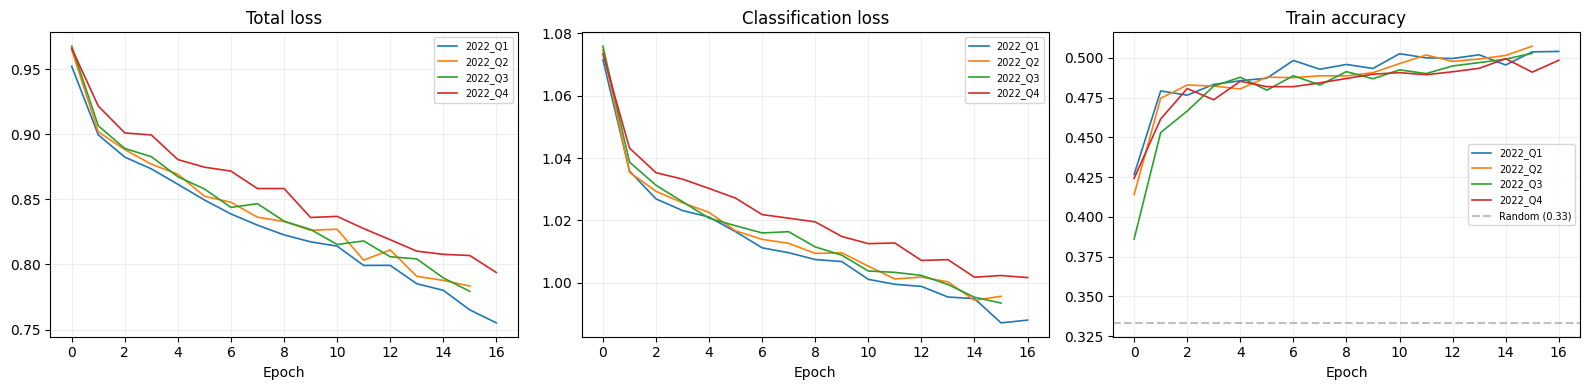

In [13]:
# ── Training curve diagnostic ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
n_samples = min(4, len(default_histories), len(eval_folds))
if n_samples == 0:
    raise RuntimeError('No baseline histories are available. Run the baseline cell before this diagnostic.')
sample_folds = np.unique(np.linspace(0, n_samples - 1, n_samples, dtype=int))

for idx in sample_folds:
    h = default_histories[idx]
    label = eval_folds[idx]["test_quarter"]
    axes[0].plot(h["total"],     label=label, linewidth=1.2)
    axes[1].plot(h["clf"],       label=label, linewidth=1.2)
    axes[2].plot(h["train_acc"], label=label, linewidth=1.2)

axes[0].set_title("Total loss");          axes[0].set_xlabel("Epoch")
axes[1].set_title("Classification loss"); axes[1].set_xlabel("Epoch")
axes[2].set_title("Train accuracy");      axes[2].set_xlabel("Epoch")
axes[2].axhline(1/3, color="gray", linestyle="--", alpha=0.5, label="Random (0.33)")

for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 6. Hyperparameter Search & Final Tuned Model

Two-phase Optuna search (TPE sampler) over `lr`, `alpha` (classification/regression loss weight), `dropout`, `batch_size`, and `weight_decay`:
- **Phase 1** tunes on folds 1–4 (2020), then evaluates on folds 5–12 (2021–2022).
- **Phase 2** retunes on folds 1–12 (2020–2022) using the extra data, then evaluates on folds 13–24 (2023–2025).

Each phase only tunes on folds that come *before* the folds it's evaluated on, so no future information leaks into the hyperparameter choice. The winning config from each phase is then used to retrain (from scratch, per fold) across every walk-forward step in that phase.


In [14]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [15]:

N_TUNE_FOLDS = 4
RETUNE_AT = 12
N_TRIALS = 24

tune_folds_phase1 = folds_data[:N_TUNE_FOLDS]
eval_folds_phase1 = folds_data[N_TUNE_FOLDS:RETUNE_AT]
tune_folds_phase2 = folds_data[:RETUNE_AT]
eval_folds_phase2 = folds_data[RETUNE_AT:]
eval_folds = folds_data[N_TUNE_FOLDS:]

print(f"Phase 1 tune:  {[f['test_quarter'] for f in tune_folds_phase1]}")
print(f"Phase 1 eval:  {[f['test_quarter'] for f in eval_folds_phase1]}")
print(f"Phase 2 tune:  folds 1-{RETUNE_AT} "
      f"({tune_folds_phase2[0]['test_quarter']} to {tune_folds_phase2[-1]['test_quarter']})")
print(f"Phase 2 eval:  {[f['test_quarter'] for f in eval_folds_phase2]}")
print()


def run_optuna_search(tune_folds, n_features, n_trials=24):
    """Bayesian HP search (TPE) for Multi-Task DNN."""

    def objective(trial):
        cfg = {
            "lr":           trial.suggest_float("lr", 5e-4, 3e-3, log=True),
            "alpha":        trial.suggest_float("alpha", 0.3, 0.9),
            "dropout":      trial.suggest_categorical("dropout", [0.2, 0.3]),
            "batch_size":   trial.suggest_categorical("batch_size", [256, 512]),
            "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
        }

        fold_aucs = []
        for tf in tune_folds:
            out = train_dnn(
                tf, n_features,
                hidden=(256, 128, 64), dropout=cfg["dropout"],
                lr=cfg["lr"], alpha=cfg["alpha"],
                batch_size=cfg["batch_size"], weight_decay=cfg["weight_decay"],
                use_class_weights=True, seed=42,
            )
            fold_aucs.append(roc_auc_score(
                tf["y_test_cls"], out["clf_probs"],
                multi_class="ovr", average="weighted"))

        return np.mean(fold_aucs)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42))

     # Enqueue default config as an explicit trial so TPE can compare against it
    study.enqueue_trial({
        "lr": 1e-3, "alpha": 0.5, "dropout": 0.3,
        "batch_size": 512, "weight_decay": 1e-4,
    })

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best = study.best_params
    best_cfg = {
        "hidden":           (256, 128, 64),
        "dropout":          best["dropout"],
        "lr":               best["lr"],
        "alpha":            best["alpha"],
        "batch_size":       best["batch_size"],
        "use_class_weights": True,
        "weight_decay":     best["weight_decay"],
    }

    print(f"  Best AUC: {study.best_value:.4f}")
    print(f"  Config:   {best_cfg}")

    return best_cfg, study


# ── Phase 1: tune on 2020, evaluate 2021–2022 ──────────────────────
print("=" * 80)
print(f"PHASE 1 — tuning on {len(tune_folds_phase1)} folds (2020)")
print("=" * 80)
best_cfg_p1, study_p1 = run_optuna_search(tune_folds_phase1, n_features, N_TRIALS)
print()

dnn_clf = {"fold_acc": [], "preds": [], "probs": [], "true": [], "quarters": []}
dnn_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
dnn_histories = []

for f in eval_folds_phase1:
    out = train_dnn(
        f, n_features,
        hidden=best_cfg_p1["hidden"], dropout=best_cfg_p1["dropout"],
        lr=best_cfg_p1["lr"], alpha=best_cfg_p1["alpha"],
        batch_size=best_cfg_p1["batch_size"],
        use_class_weights=best_cfg_p1["use_class_weights"],
        weight_decay=best_cfg_p1["weight_decay"],
        seed=42 + f["fold_num"],
    )

    acc  = accuracy_score(f["y_test_cls"], out["clf_preds"])
    dnn_clf["fold_acc"].append(acc)
    dnn_clf["preds"].extend(out["clf_preds"])
    dnn_clf["probs"].append(out["clf_probs"])
    dnn_clf["true"].extend(f["y_test_cls"])
    dnn_clf["quarters"].append(f["test_quarter"])

    mae  = mean_absolute_error(f["y_test_ret"], out["reg_preds"])
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], out["reg_preds"]))
    dnn_reg["fold_mae"].append(mae)
    dnn_reg["fold_rmse"].append(rmse)
    dnn_reg["preds"].extend(out["reg_preds"])
    dnn_reg["true"].extend(f["y_test_ret"])
    dnn_histories.append(out["history"])

    pred_dist = np.bincount(out["clf_preds"].astype(int), minlength=3)
    train_acc = out["history"]["train_acc"][-1]

    print(f"Fold {f['fold_num']:2d} [{f['test_quarter']}]: "
          f"DA={acc:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  "
          f"train_acc={train_acc:.4f}  "
          f"best_epoch={out['best_epoch']}  "
          f"pred_dist={pred_dist}")


# ── Phase 2: retune on 2020–2022, evaluate 2023–2025 ───────────────
print(f"\n{'=' * 80}")
print(f"PHASE 2 — retuning on {len(tune_folds_phase2)} folds (2020–2022)")
print(f"{'=' * 80}")
best_cfg_p2, study_p2 = run_optuna_search(tune_folds_phase2, n_features, N_TRIALS)
print()

for f in eval_folds_phase2:
    out = train_dnn(
        f, n_features,
        hidden=best_cfg_p2["hidden"], dropout=best_cfg_p2["dropout"],
        lr=best_cfg_p2["lr"], alpha=best_cfg_p2["alpha"],
        batch_size=best_cfg_p2["batch_size"],
        use_class_weights=best_cfg_p2["use_class_weights"],
        weight_decay=best_cfg_p2["weight_decay"],
        seed=42 + f["fold_num"],
    )

    acc  = accuracy_score(f["y_test_cls"], out["clf_preds"])
    dnn_clf["fold_acc"].append(acc)
    dnn_clf["preds"].extend(out["clf_preds"])
    dnn_clf["probs"].append(out["clf_probs"])
    dnn_clf["true"].extend(f["y_test_cls"])
    dnn_clf["quarters"].append(f["test_quarter"])

    mae  = mean_absolute_error(f["y_test_ret"], out["reg_preds"])
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], out["reg_preds"]))
    dnn_reg["fold_mae"].append(mae)
    dnn_reg["fold_rmse"].append(rmse)
    dnn_reg["preds"].extend(out["reg_preds"])
    dnn_reg["true"].extend(f["y_test_ret"])
    dnn_histories.append(out["history"])

    pred_dist = np.bincount(out["clf_preds"].astype(int), minlength=3)
    train_acc = out["history"]["train_acc"][-1]

    print(f"Fold {f['fold_num']:2d} [{f['test_quarter']}]: "
          f"DA={acc:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  "
          f"train_acc={train_acc:.4f}  "
          f"best_epoch={out['best_epoch']}  "
          f"pred_dist={pred_dist}")


# ── Combined results across all 20 eval folds ──────────────────────
true  = np.array(dnn_clf["true"])
preds = np.array(dnn_clf["preds"])
probs = np.vstack(dnn_clf["probs"])

print(f"\nDNN (tuned) -- Avg DA:     {np.mean(dnn_clf['fold_acc']):.4f}")
print(f"DNN (tuned) -- Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"DNN (tuned) -- Pooled AUC: {roc_auc_score(true, probs, multi_class='ovr', average='weighted'):.4f}")

true_r  = np.array(dnn_reg["true"])
preds_r = np.array(dnn_reg["preds"])
print(f"\nDNN (tuned) -- Avg MAE:  {np.mean(dnn_reg['fold_mae']):.4f}")
print(f"DNN (tuned) -- Avg RMSE: {np.mean(dnn_reg['fold_rmse']):.4f}")
print(f"DNN (tuned) -- Pooled R²: {r2_score(true_r, preds_r):.4f}")

print(f"\nPhase 1 config: {best_cfg_p1}")
print(f"Phase 2 config: {best_cfg_p2}")

print("\n" + classification_report(true, preds,
      target_names=["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]))
print("Confusion matrix:\n", confusion_matrix(true, preds))

# ── Tuning folds for completeness ───────────────────────────────────
print("\n--- Tuning folds (2020, used for HP selection *) ---")
for f in tune_folds_phase1:
    out = train_dnn(
        f, n_features,
        hidden=best_cfg_p1["hidden"], dropout=best_cfg_p1["dropout"],
        lr=best_cfg_p1["lr"], alpha=best_cfg_p1["alpha"],
        batch_size=best_cfg_p1["batch_size"],
        use_class_weights=best_cfg_p1["use_class_weights"],
        weight_decay=best_cfg_p1["weight_decay"],
        seed=42 + f["fold_num"],
    )
    acc = accuracy_score(f["y_test_cls"], out["clf_preds"])
    print(f"Fold {f['fold_num']:2d} [{f['test_quarter']}] *: "
          f"DA={acc:.4f}  best_epoch={out['best_epoch']}")

Phase 1 tune:  ['2021_Q1', '2021_Q2', '2021_Q3', '2021_Q4']
Phase 1 eval:  ['2022_Q1', '2022_Q2', '2022_Q3', '2022_Q4', '2023_Q1', '2023_Q2', '2023_Q3', '2023_Q4']
Phase 2 tune:  folds 1-12 (2021_Q1 to 2023_Q4)
Phase 2 eval:  ['2024_Q1', '2024_Q2', '2024_Q3', '2024_Q4', '2025_Q1', '2025_Q2', '2025_Q3', '2025_Q4']

PHASE 1 — tuning on 4 folds (2020)


Best trial: 16. Best value: 0.60803: 100%|██████████| 24/24 [04:47<00:00, 11.99s/it]


  Best AUC: 0.6080
  Config:   {'hidden': (256, 128, 64), 'dropout': 0.3, 'lr': 0.0005041437168772124, 'alpha': 0.3108725866741314, 'batch_size': 256, 'use_class_weights': True, 'weight_decay': 0.0002379353796059849}

Fold  5 [2022_Q1]: DA=0.4798  MAE=0.0366  RMSE=0.0523  train_acc=0.4968  best_epoch=1  pred_dist=[  9   4 481]
Fold  6 [2022_Q2]: DA=0.3717  MAE=0.0433  RMSE=0.0513  train_acc=0.4959  best_epoch=0  pred_dist=[ 21   2 472]
Fold  7 [2022_Q3]: DA=0.5477  MAE=0.0269  RMSE=0.0344  train_acc=0.4910  best_epoch=0  pred_dist=[  5 126 362]
Fold  8 [2022_Q4]: DA=0.6998  MAE=0.0382  RMSE=0.0533  train_acc=0.4887  best_epoch=1  pred_dist=[  9  20 464]
Fold  9 [2023_Q1]: DA=0.4553  MAE=0.0253  RMSE=0.0333  train_acc=0.4948  best_epoch=0  pred_dist=[220  24 248]
Fold 10 [2023_Q2]: DA=0.4398  MAE=0.0248  RMSE=0.0382  train_acc=0.5041  best_epoch=1  pred_dist=[251  25 222]
Fold 11 [2023_Q3]: DA=0.4597  MAE=0.0203  RMSE=0.0303  train_acc=0.5036  best_epoch=5  pred_dist=[291 130  75]
Fold 

Best trial: 3. Best value: 0.619225: 100%|██████████| 24/24 [15:04<00:00, 37.67s/it]


  Best AUC: 0.6192
  Config:   {'hidden': (256, 128, 64), 'dropout': 0.3, 'lr': 0.0006925598810528834, 'alpha': 0.41004270591206027, 'batch_size': 256, 'use_class_weights': True, 'weight_decay': 0.00016738085788752134}

Fold 13 [2024_Q1]: DA=0.3589  MAE=0.0265  RMSE=0.0425  train_acc=0.5002  best_epoch=0  pred_dist=[389  19  88]
Fold 14 [2024_Q2]: DA=0.3932  MAE=0.0264  RMSE=0.0400  train_acc=0.5050  best_epoch=3  pred_dist=[248  90 163]
Fold 15 [2024_Q3]: DA=0.4068  MAE=0.0272  RMSE=0.0371  train_acc=0.4955  best_epoch=1  pred_dist=[157 109 233]
Fold 16 [2024_Q4]: DA=0.3968  MAE=0.0336  RMSE=0.0602  train_acc=0.5091  best_epoch=12  pred_dist=[ 84 225 195]
Fold 17 [2025_Q1]: DA=0.3845  MAE=0.0273  RMSE=0.0386  train_acc=0.4970  best_epoch=3  pred_dist=[181  64 257]
Fold 18 [2025_Q2]: DA=0.6327  MAE=0.0352  RMSE=0.0554  train_acc=0.4933  best_epoch=0  pred_dist=[ 56  17 428]
Fold 19 [2025_Q3]: DA=0.3964  MAE=0.0250  RMSE=0.0387  train_acc=0.4900  best_epoch=0  pred_dist=[273  69 160]
Fo

## 7. Visualizations — Evaluation & Interpretation

Plots below are built from the pooled results of the tuned model across all 20 evaluation folds (`dnn_clf`, `dnn_reg`) computed in Section 6.


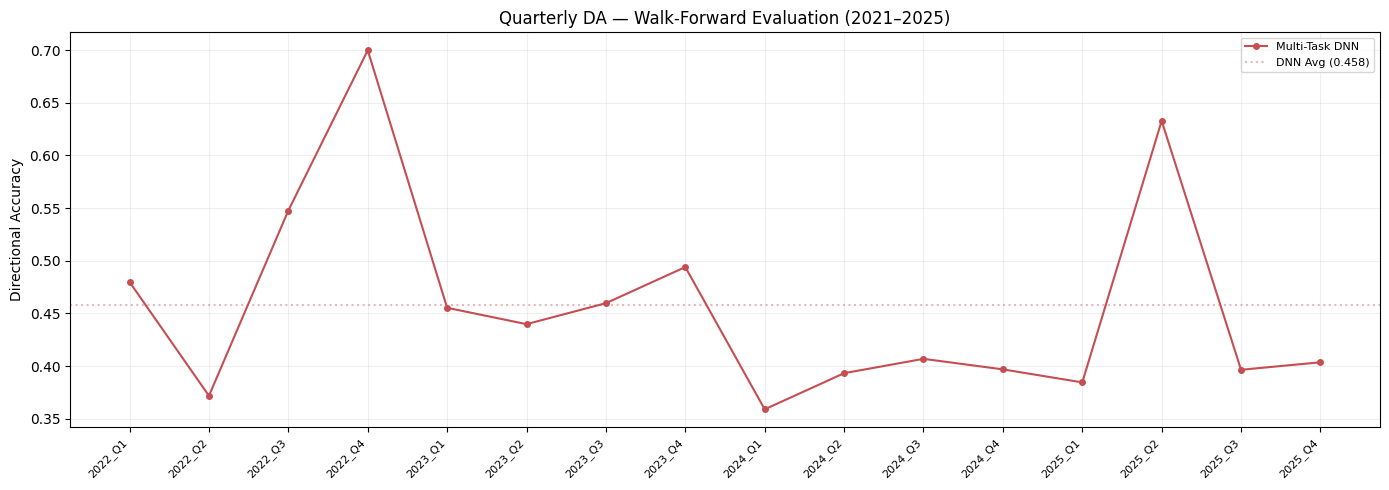

In [16]:

# ── Quarterly DA over time ──────────────────────────────────────────
labels = dnn_clf["quarters"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, dnn_clf["fold_acc"], marker="o", markersize=4, linewidth=1.5,
        color="#C44E52", label="Multi-Task DNN")
ax.axhline(np.mean(dnn_clf["fold_acc"]), color="#C44E52", linestyle=":",
           alpha=0.4, label=f"DNN Avg ({np.mean(dnn_clf['fold_acc']):.3f})")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Directional Accuracy")
ax.set_title("Quarterly DA — Walk-Forward Evaluation (2021–2025)")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Confusion Matrix

Row-normalized view of the same numbers in the per-class table above — visually, Hold's row should show the least concentration on its own diagonal cell.

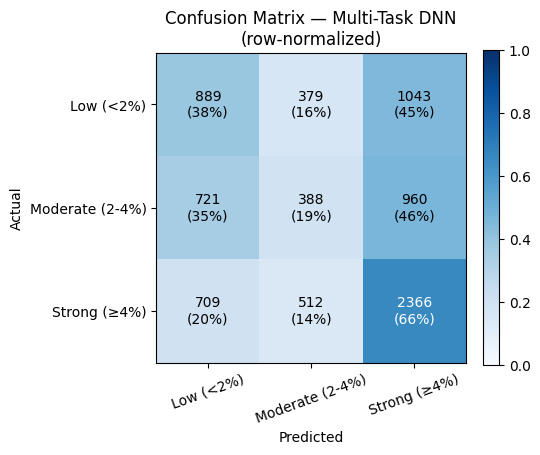

In [17]:
# ── Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(true, preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]
ax.set_xticks(range(3)); ax.set_xticklabels(labels, rotation=20)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Multi-Task DNN\n(row-normalized)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]}\n({cm_pct[i,j]:.0%})", ha="center", va="center",
                color="white" if cm_pct[i,j] > 0.5 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

### Actual Return Distribution by Predicted Class

Boxplots of the true `target_return` values, grouped by what the classifier predicted. If the classification head is doing its job, the box for "Predicted Strong" should sit meaningfully above the 4% threshold line, with the three boxes ordered Low < Moderate < Strong.


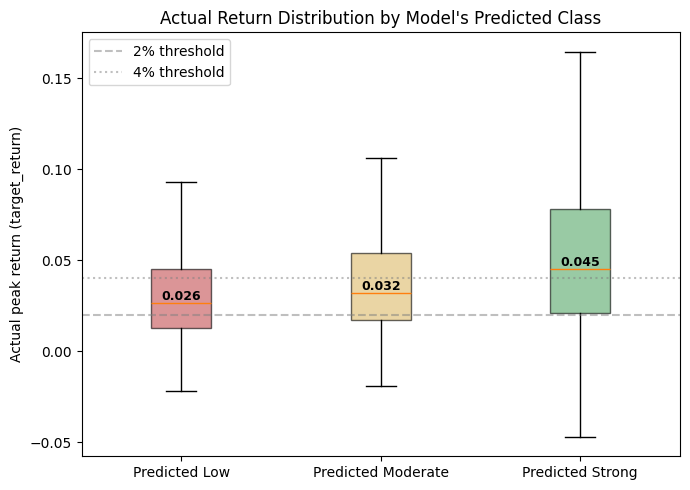

In [18]:
# ── Actual Return Distribution by Predicted Class ───────────────────
fig, ax = plt.subplots(figsize=(7, 5))
data_by_class = [true_r[preds == c] for c in [0, 1, 2]]
bp = ax.boxplot(data_by_class,
                tick_labels=["Predicted Low", "Predicted Moderate", "Predicted Strong"],
                showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#C44E52", "#DDB967", "#55A868"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)

for i, data in enumerate(data_by_class):
    median = np.median(data)
    ax.text(i + 1, median, f"{median:.3f}", ha="center", va="bottom",
            fontweight="bold", fontsize=9)

ax.axhline(0.02, color="gray", linestyle="--", alpha=0.5, label="2% threshold")
ax.axhline(0.04, color="gray", linestyle=":", alpha=0.5, label="4% threshold")
ax.set_ylabel("Actual peak return (target_return)")
ax.set_title("Actual Return Distribution by Model's Predicted Class")
ax.legend()
plt.tight_layout()
plt.show()

### Tuned-Model Training Curves

Same diagnostic as the baseline version in Section 5, but now including validation loss (used for early stopping) alongside train loss/accuracy, for the same sample folds under the tuned hyperparameters. Useful for comparing convergence behavior against the baseline plot.


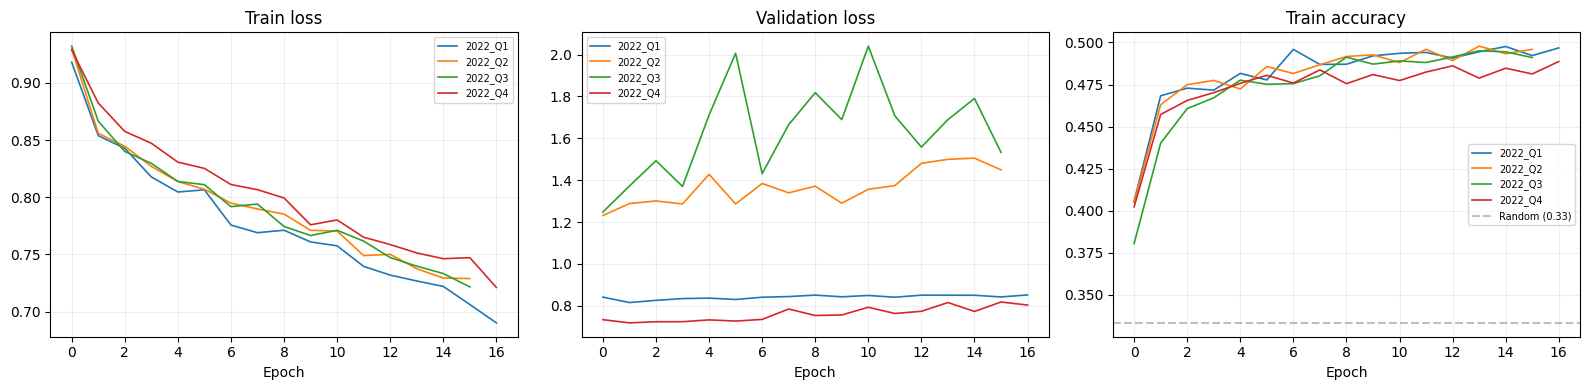

In [19]:
# ── Training curve with val loss ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
n_samples = min(4, len(dnn_histories), len(dnn_clf['quarters']))
if n_samples == 0:
    raise RuntimeError('No tuned histories are available. Run the tuned-model cell before this diagnostic.')
sample_folds = np.unique(np.linspace(0, n_samples - 1, n_samples, dtype=int))

for idx in sample_folds:
    h = dnn_histories[idx]
    label = dnn_clf["quarters"][idx]
    axes[0].plot(h["total"],     label=label, linewidth=1.2)
    axes[1].plot(h["val_loss"],  label=label, linewidth=1.2)
    axes[2].plot(h["train_acc"], label=label, linewidth=1.2)

axes[0].set_title("Train loss");     axes[0].set_xlabel("Epoch")
axes[1].set_title("Validation loss"); axes[1].set_xlabel("Epoch")
axes[2].set_title("Train accuracy");  axes[2].set_xlabel("Epoch")
axes[2].axhline(1/3, color="gray", linestyle="--", alpha=0.5, label="Random (0.33)")

for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 8. Model Diagnostics — Understanding What the Model Learned

Six diagnostics, each isolating a different question about model behavior: where classification errors concentrate (precision/recall), whether the regression head tracks the classification head (predicted vs. actual), whether confidence is a useful reliability signal, whether performance held up across the two tuning phases, how the two loss terms trade off during training, and a single consolidated results table.


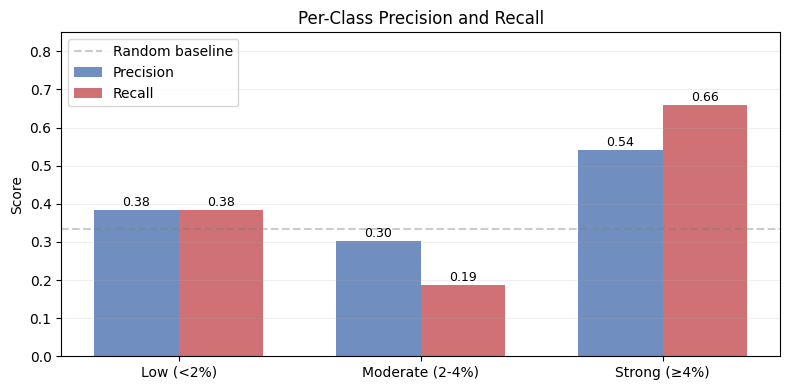

In [20]:

# ── 1. Per-Class Precision vs Recall ────────────────────────────────
class_labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]
precisions = precision_score(true, preds, average=None)
recalls = recall_score(true, preds, average=None)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, precisions, w, label="Precision", color="#4C72B0", alpha=0.8)
ax.bar(x + w/2, recalls, w, label="Recall", color="#C44E52", alpha=0.8)
for i in range(3):
    ax.text(i - w/2, precisions[i] + 0.01, f"{precisions[i]:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, recalls[i] + 0.01, f"{recalls[i]:.2f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision and Recall")
ax.set_ylim(0, 0.85)
ax.axhline(1/3, color="gray", linestyle="--", alpha=0.4, label="Random baseline")
ax.legend()
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

### Predicted vs. Actual Returns (Regression Head)

Scatter of predicted vs. actual peak return, pooled across all evaluation folds. Points near the red diagonal are well-calibrated predictions; the pooled R² summarizes the overall fit.


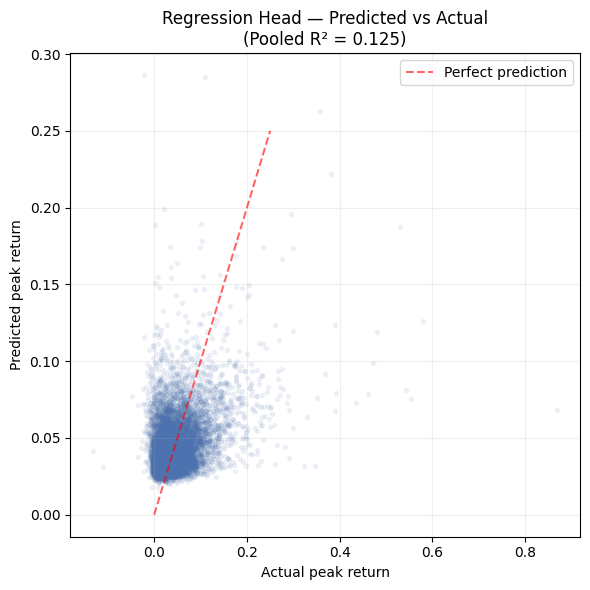

In [21]:
# ── 2. Predicted vs Actual Returns (Regression Head) ────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_r, preds_r, alpha=0.08, s=8, color="#4C72B0")
ax.plot([0, 0.25], [0, 0.25], color="red", linestyle="--", alpha=0.6, label="Perfect prediction")
ax.set_xlabel("Actual peak return")
ax.set_ylabel("Predicted peak return")
ax.set_title(f"Regression Head — Predicted vs Actual\n(Pooled R² = {r2_score(true_r, preds_r):.3f})")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Prediction Confidence Distribution

Compares the classifier's max softmax probability for correct vs. incorrect predictions. Separation between the two distributions (correct predictions skewed high, wrong predictions closer to the 0.33 random baseline) would suggest confidence is a usable signal for filtering low-quality predictions downstream.


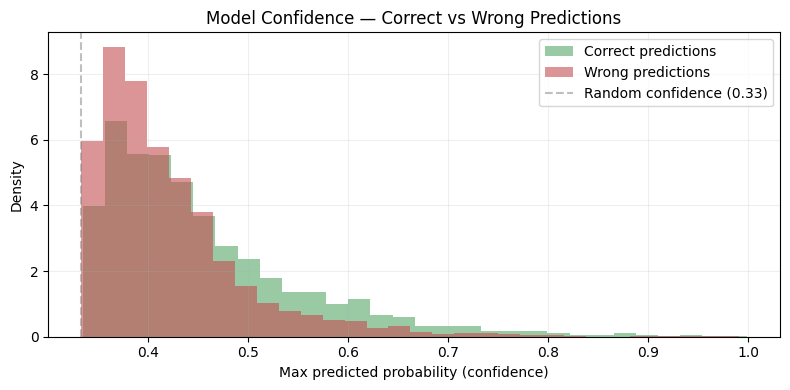

In [22]:
# ── 3. Prediction Confidence Distribution ───────────────────────────
max_probs = np.max(np.vstack(dnn_clf["probs"]), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(max_probs[preds == true], bins=30, alpha=0.6, color="#55A868", label="Correct predictions", density=True)
ax.hist(max_probs[preds != true], bins=30, alpha=0.6, color="#C44E52", label="Wrong predictions", density=True)
ax.axvline(1/3, color="gray", linestyle="--", alpha=0.5, label="Random confidence (0.33)")
ax.set_xlabel("Max predicted probability (confidence)")
ax.set_ylabel("Density")
ax.set_title("Model Confidence — Correct vs Wrong Predictions")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Directional Accuracy by Tuning Phase

Splits the 20 evaluation folds by which Optuna phase produced their hyperparameters (Phase 1 → 2021–2022, Phase 2 → 2023–2025) to check whether retuning on more data in Phase 2 held up out-of-sample, or whether performance drifted between the two periods.


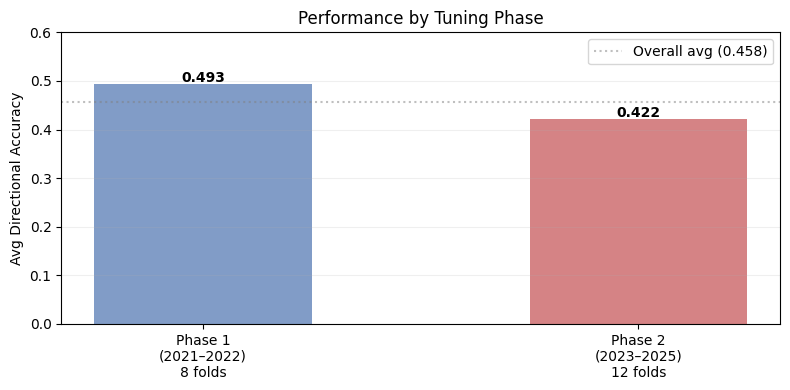

In [23]:
# ── 4. DA by Phase ──────────────────────────────────────────────────
phase1_accs = dnn_clf["fold_acc"][:8]
phase2_accs = dnn_clf["fold_acc"][8:]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Phase 1\n(2021–2022)\n8 folds", "Phase 2\n(2023–2025)\n12 folds"],
       [np.mean(phase1_accs), np.mean(phase2_accs)],
       color=["#4C72B0", "#C44E52"], alpha=0.7, width=0.5)
ax.axhline(np.mean(dnn_clf["fold_acc"]), color="gray", linestyle=":",
           alpha=0.5, label=f"Overall avg ({np.mean(dnn_clf['fold_acc']):.3f})")
for i, val in enumerate([np.mean(phase1_accs), np.mean(phase2_accs)]):
    ax.text(i, val + 0.005, f"{val:.3f}", ha="center", fontweight="bold")
ax.set_ylabel("Avg Directional Accuracy")
ax.set_title("Performance by Tuning Phase")
ax.legend()
ax.set_ylim(0, 0.6)
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

### Multi-Task Loss Contribution

**Left:** how the classification and regression loss terms (and their weighted sum) evolve during training for the most recent fold — shows whether one task is dominating the joint loss. **Right:** distribution of the regression head's predicted returns, broken out by which class the classification head assigned — checks that the two heads agree with each other, even though they're only linked through the shared encoder.


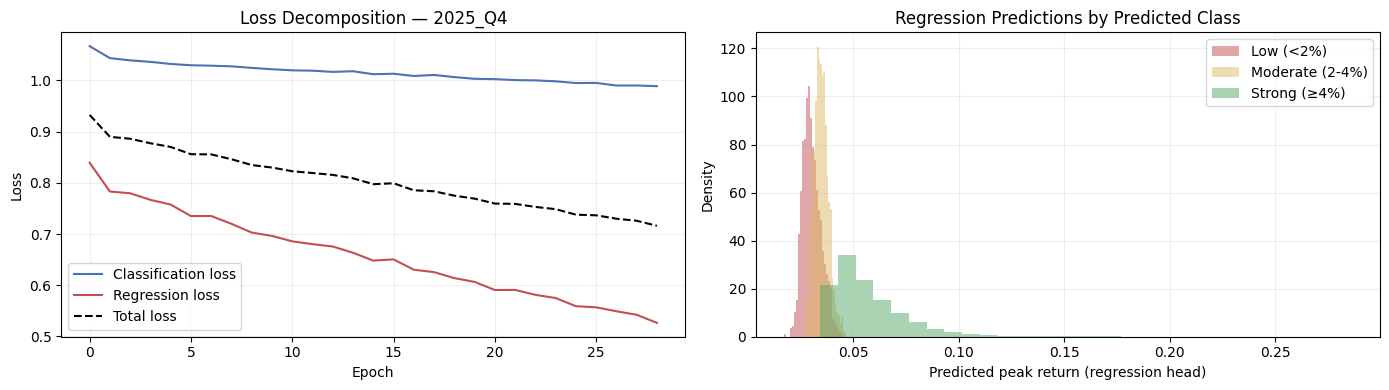

In [24]:
# ── 5. Multi-Task Contribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sample_idx = len(dnn_histories) - 1
h = dnn_histories[sample_idx]
epochs = range(len(h["total"]))

axes[0].plot(epochs, h["clf"], label="Classification loss", color="#4C72B0", linewidth=1.5)
axes[0].plot(epochs, h["reg"], label="Regression loss", color="#C44E52", linewidth=1.5)
axes[0].plot(epochs, h["total"], label="Total loss", color="black", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"Loss Decomposition — {dnn_clf['quarters'][-1]}")
axes[0].legend()
axes[0].grid(alpha=0.2)

class_labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]
for c, (label, color) in enumerate(zip(class_labels, ["#C44E52", "#DDB967", "#55A868"])):
    mask = preds == c
    if mask.sum() > 0:
        axes[1].hist(preds_r[mask], bins=30, alpha=0.5, label=label, color=color, density=True)
axes[1].set_xlabel("Predicted peak return (regression head)")
axes[1].set_ylabel("Density")
axes[1].set_title("Regression Predictions by Predicted Class")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Summary Table

Consolidates the headline numbers from this run — directional accuracy, AUC, F1 for classification; R², MAE, RMSE for regression — plus the two winning hyperparameter configs, for pasting straight into the report.


In [25]:
# ── 6. Summary Table ────────────────────────────────────────────────
print("=" * 60)
print("MULTI-TASK DNN — FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset:          ~24,000 earnings events (2014–2025)")
print(f"  Features:         {n_features} (technical + fundamental + sentiment + sector)")
print(f"  Architecture:     Shared encoder [256,128,64] + dual heads")
print(f"  Evaluation:       {len(dnn_clf['fold_acc'])} quarterly walk-forward folds")
print(f"  HP optimization:  Optuna TPE, two-phase expanding window")
print(f"  Early stopping:   val = quarter before test, min_epochs=15, patience=15")
print(f"")
print(f"  CLASSIFICATION (3-class):")
print(f"    Avg DA:         {np.mean(dnn_clf['fold_acc']):.4f}  (random baseline: 0.333)")
print(f"    Pooled AUC:     {roc_auc_score(true, probs, multi_class='ovr', average='weighted'):.4f}")
print(f"    Pooled F1:      {f1_score(true, preds, average='weighted'):.4f}")
print(f"    Strong (≥4%) F1: {f1_score(true, preds, average=None)[2]:.4f}")
print(f"")
print(f"  REGRESSION:")
print(f"    Pooled R²:      {r2_score(true_r, preds_r):.4f}")
print(f"    Avg MAE:        {np.mean(dnn_reg['fold_mae']):.4f}")
print(f"    Avg RMSE:       {np.mean(dnn_reg['fold_rmse']):.4f}")
print(f"")
print(f"  Phase 1 config:   {best_cfg_p1}")
print(f"  Phase 2 config:   {best_cfg_p2}")
print("=" * 60)

MULTI-TASK DNN — FINAL RESULTS SUMMARY
  Dataset:          ~24,000 earnings events (2014–2025)
  Features:         257 (technical + fundamental + sentiment + sector)
  Architecture:     Shared encoder [256,128,64] + dual heads
  Evaluation:       16 quarterly walk-forward folds
  HP optimization:  Optuna TPE, two-phase expanding window
  Early stopping:   val = quarter before test, min_epochs=15, patience=15

  CLASSIFICATION (3-class):
    Avg DA:         0.4575  (random baseline: 0.333)
    Pooled AUC:     0.6099
    Pooled F1:      0.4394
    Strong (≥4%) F1: 0.5948

  REGRESSION:
    Pooled R²:      0.1250
    Avg MAE:        0.0296
    Avg RMSE:       0.0428

  Phase 1 config:   {'hidden': (256, 128, 64), 'dropout': 0.3, 'lr': 0.0005041437168772124, 'alpha': 0.3108725866741314, 'batch_size': 256, 'use_class_weights': True, 'weight_decay': 0.0002379353796059849}
  Phase 2 config:   {'hidden': (256, 128, 64), 'dropout': 0.3, 'lr': 0.0006925598810528834, 'alpha': 0.41004270591206027,

## 9. Save Results

Pickles the tuned-phase configs, pooled classification/regression outputs, and per-fold training histories to Drive, keyed for later comparison against the other B1–B7 pipelines.


In [26]:
# Legacy pickle export intentionally replaced by the final parquet/JSON export cell below.

In [27]:
# ── Local output export ─────────────────────────────────────────────
# Keep the existing notebook results; only serialize them for downstream use.
output_dir = MODEL_STAGING_DIR.parent.parent / 'modeling' / 'model_outputs' / 'dnn_outputs'
output_dir.mkdir(parents=True, exist_ok=True)

# Recover the event metadata in the same quarter/order as the test folds.
event_rows = []
for quarter in dnn_clf['quarters']:
    year, qtr = (int(x) for x in quarter.split('_Q'))
    event_rows.extend(df_model.filter((pl.col('year') == year) & (pl.col('quarter') == qtr)).select(['symbol', 'earnings_date', 'entry_price']).to_dicts())

if len(event_rows) != len(dnn_clf['preds']):
    raise ValueError(f'Metadata/prediction length mismatch: {len(event_rows)} != {len(dnn_clf["preds"])}')

probs = np.vstack(dnn_clf['probs'])
fold_nums = np.concatenate([np.full(len(df_model.filter((pl.col('year') == int(q.split('_Q')[0])) & (pl.col('quarter') == int(q.split('_Q')[1])))), i + 1) for i, q in enumerate(dnn_clf['quarters'])])
results_df = pl.DataFrame({
    'quarter': np.repeat(dnn_clf['quarters'], [len(df_model.filter((pl.col('year') == int(q.split('_Q')[0])) & (pl.col('quarter') == int(q.split('_Q')[1])))) for q in dnn_clf['quarters']]),
    'fold_num': fold_nums,
    'symbol': [r['symbol'] for r in event_rows],
    'earnings_date': [r['earnings_date'] for r in event_rows],
    'entry_price': [r['entry_price'] for r in event_rows],
    'target_class_actual': dnn_clf['true'],
    'target_class_predicted': dnn_clf['preds'],
    'prob_class_0': probs[:, 0], 'prob_class_1': probs[:, 1], 'prob_class_2': probs[:, 2],
    'target_return_actual': dnn_reg['true'],
    'target_return_predicted': dnn_reg['preds'],
})
summary_df = pl.DataFrame({'quarter': dnn_clf['quarters'], 'fold_num': range(1, len(dnn_clf['quarters']) + 1), 'DA': dnn_clf['fold_acc'], 'MAE': dnn_reg['fold_mae'], 'RMSE': dnn_reg['fold_rmse']})
results_df.write_parquet(output_dir / 'results.parquet')
summary_df.write_parquet(output_dir / 'per_fold_summary.parquet')

histories = dict(zip(dnn_clf['quarters'], dnn_histories))
(output_dir / 'histories_clf.json').write_text(json.dumps(histories, indent=2))
(output_dir / 'histories_reg.json').write_text(json.dumps(histories, indent=2))
(output_dir / 'feature_importance.json').write_text(json.dumps({'feature_names': flat_feature_cols, 'clf': {}, 'reg': {}}, indent=2))
(output_dir / 'attention_masks.json').write_text(json.dumps({'feature_names': flat_feature_cols, 'clf': {}, 'reg': {}}, indent=2))
print(f'Saved DNN outputs to {output_dir}')

Saved DNN outputs to /Users/richardpears/github/Post-Earnings-Forecast/src/modeling/model_outputs/dnn_outputs
